## **Import libraries**

In [1]:
from __future__ import annotations

import os
import torch
import random
import traceback
import numpy as np
import pandas as pd
from typing import TYPE_CHECKING
from transformers import set_seed as transformers_set_seed

from pathlib import Path
from tqdm.auto import tqdm
from natsort import natsorted

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.models.schemas import (
    DOCXToJSONSConfig
)

if TYPE_CHECKING:
    from SARVI.models.schemas import PipelineContext

from SARVI.data_io.reader import (
    textwrap,
    read_docx_single, read_docx_list, read_txt_list,
    read_json_single,
    read_excel_single,
    read_ann_list
)
from SARVI.data_io.writing import (
    create_intermediate_folder_name,
    write_json, write_ann_list
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    model_ner,
    tokenizer_ner,
    initialize_span_ner_model, initialize_bio_ner_model,
    create_ultimate_df_ann
)
from SARVI.services.common.re_funcs import (
    initialize_re_model
)
from SARVI.services.common.att_funcs import (
    initialize_att_model
)
from SARVI.services.common.icd_pred_funcs import(
    initialize_icd10_hs_head_model,
    initialize_icd10_hs_prediction_model,
    initialize_icd10_no_hs_head_model,
    result_item_to_diagnostico
)
from SARVI.services.common.utils.json_utils import (
    validate_json_created
)
from SARVI.services.common.utils.ann_utils import (
    ner_outputs_to_ann, re_outputs_to_ann, att_outputs_to_ann, icd_outputs_to_ann
)
from SARVI.services.common.utils.nn_utils import (
    ensure_entity_marker_tokens
)

from SARVI.services.sync_funcs.llm_funcs import (
    process_docx as process_docx_SYNC,
)
from SARVI.services.sync_funcs.ner_funcs import (
    prepare_data as prepare_data_ner_SYNC,
    construct_loaders_ner as construct_loaders_ner_SYNC,
    run_bio_nerclassifier as run_bio_nerclassifier_SYNC,
    run_span_nerclassifier as run_span_nerclassifier_SYNC,
)
from SARVI.services.sync_funcs.re_funcs import (
    prepare_data as prepare_data_re_SYNC,
    construct_loader_re as construct_loader_re_SYNC,
    run_re_classifier as run_re_classifier_SYNC
)
from SARVI.services.sync_funcs.att_funcs import (
    prepare_data as prepare_data_att_SYNC,
    construct_loader_att as construct_loader_att_SYNC,
    run_att_classifier as run_att_classifier_SYNC
)
from SARVI.services.sync_funcs.icd_pred_funcs import(
    prepare_data as prepare_data_icd_SYNC,
    construct_loaders_icd as construct_loaders_icd_SYNC,
    run_icd_classifier as run_icd_classifier_SYNC,
    create_mixed_icd10_threshold_results as create_mixed_icd10_threshold_results_SYNC,
)

from SARVI.services.async_funcs.llm_funcs import (
    asyncio,
    process_docx as process_docx_ASYNC
)

from SARVI.models.schemas import LLMConfig, PipelineContext
from SARVI.config import paths

Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[2026-06-09 16:05:27] INFO SentenceTransformer.py:219: Use pytorch device_name: cuda:0
[2026-06-09 16:05:27] INFO SentenceTransformer.py:227: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: "PipelineContext"):
    print("\n\033[1m0. Initializing variables\033[0m\n\n")
    create_intermediate_folder_name(ctx)

    #################################################################################################################
    print("\n\033[1m0.1. Reading ICD10 dictionaries\033[0m\n\n")

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())

    if ctx.ussage == "generative":
        print("\n\033[1m0.2. Initializing LLM\033[0m\n\n")

        # llm = load_llm(ctx.llm_config)
        # prompt = textwrap.dedent(prompts_total["report_to_data"])
        llm = None
        prompt = None
        modelo_ner = None
        modelo_re = None
        modelo_att = None
        tokenizer_re = None
        tokenizer_att = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_NER = None
        id2label_NER = None
        label2id_RE = None
        id2label_RE = None
        label2id_ATT = None
        id2label_ATT = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        re_token_distance_bins = None
        re_negative_difficulty_by_bin = None
        icd10_thresholds = None
        root = None
    else:
        llm = None
        prompt = None

        # ------------------------------NER------------------------------
        # [BIO, Span]
        print("\n\033[1m0.1. Initializing NER Models\033[0m\n\n")

        id2label_ner_bio = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/CT-EBM-SP/id2label_bio_nerclassifier.json")
        id2label_ner_bio = {int(k): v for k, v in id2label_ner_bio.items()}
        label2id_ner_bio = {v: int(k)  for k, v in id2label_ner_bio.items()}

        id2label_ner_span = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/CT-EBM-SP/id2label_span_nerclassifier.json")
        id2label_ner_span = {int(k): v for k, v in id2label_ner_span.items()}
        label2id_ner_span = {v: int(k)  for k, v in id2label_ner_span.items()}

        id2label_NER = [id2label_ner_bio, id2label_ner_span]
        label2id_NER = [label2id_ner_bio, label2id_ner_span]

        modelo_ner = [
            initialize_bio_ner_model(ctx, None, len(id2label_ner_bio), "NERTraining/BIO/CT-EBM-SP/bio_nerclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name),
            initialize_span_ner_model(ctx, None, len(id2label_ner_span), id2label_ner_span, label2id_ner_span, None, "NERTraining/Span/CT-EBM-SP/span_nerclassifier_checkpoint.pt", True, base_encoder_name=ctx.base_encoder_name)
        ]

        # ------------------------------RE------------------------------
        # [Experience, Negation, Speculation, Time]
        print("\n\033[1m0.3. Initializing RE Models\033[0m\n\n")

        re_token_distance_bins = {0: (0, 0), 1: (1, 2), 2: (3, 5), 3: (6, 10), 4: (11, 20), 5: (21, 40), 6: (41, 80), 7: (81, 160), 8: (161, float("inf"))}
        re_negative_difficulty_by_bin = {0: "hard", 1: "hard", 2: "hard", 3: "hard", 4: "medium", 5: "medium", 6: "easy", 7: "easy", 8: "easy"}

        id2label_re_experience = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_LIVB/id2label_diso_livb_reclassifier.json")
        id2label_re_experience = {int(k): v for k, v in id2label_re_experience.items()}
        label2id_re_experience = {v: int(k)  for k, v in id2label_re_experience.items()}

        id2label_re_negation = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_Negcue/id2label_diso_negcue_reclassifier.json")
        id2label_re_negation = {int(k): v for k, v in id2label_re_negation.items()}
        label2id_re_negation = {v: int(k)  for k, v in id2label_re_negation.items()}

        id2label_re_speculation = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_Speccue/id2label_diso_speccue_reclassifier.json")
        id2label_re_speculation = {int(k): v for k, v in id2label_re_speculation.items()}
        label2id_re_speculation = {v: int(k)  for k, v in id2label_re_speculation.items()}

        id2label_re_time = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_Date/id2label_diso_date_reclassifier.json")
        id2label_re_time = {int(k): v for k, v in id2label_re_time.items()}
        label2id_re_time = {v: int(k)  for k, v in id2label_re_time.items()}

        id2label_RE = [id2label_re_experience, id2label_re_negation, id2label_re_speculation, id2label_re_time]
        label2id_RE = [label2id_re_experience, label2id_re_negation, label2id_re_speculation, label2id_re_time]

        tokenizer_re = [
            ensure_entity_marker_tokens(None, ["DISO", "LIVB"], "re", base_encoder_name=ctx.base_encoder_name),
            ensure_entity_marker_tokens(None, ["DISO", "Neg_cue"], "re", base_encoder_name=ctx.base_encoder_name),
            ensure_entity_marker_tokens(None, ["DISO", "Spec_cue"], "re", base_encoder_name=ctx.base_encoder_name),
            ensure_entity_marker_tokens(None, ["DISO", "Date"], "re", base_encoder_name=ctx.base_encoder_name)
        ]

        modelo_re = [
            initialize_re_model(ctx, None, len(id2label_re_experience), len(re_token_distance_bins), "RETraining/DISO_LIVB/diso_livb_reclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_re[0]),
            initialize_re_model(ctx, None, len(id2label_re_negation), len(re_token_distance_bins), "RETraining/DISO_Negcue/diso_negcue_reclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_re[1]),
            initialize_re_model(ctx, None, len(id2label_re_speculation), len(re_token_distance_bins), "RETraining/DISO_Speccue/diso_speccue_reclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_re[2]),
            initialize_re_model(ctx, None, len(id2label_re_time), len(re_token_distance_bins), "RETraining/DISO_Date/diso_date_reclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_re[3])
        ]

        # ------------------------------ATT------------------------------
        # [Status]
        print("\n\033[1m0.4. Initializing ATT Model\033[0m\n\n")

        id2label_att_status = read_json_single(ctx.paths.docs_dir / "ATTTraining/Status/id2label_status_attclassifier.json")
        id2label_att_status = {int(k): v for k, v in id2label_att_status.items()}
        label2id_att_status = {v: int(k)  for k, v in id2label_att_status.items()}

        id2label_ATT = [id2label_att_status]
        label2id_ATT = [label2id_att_status]

        tokenizer_att = [
            ensure_entity_marker_tokens(None, ["DISO"], "att", base_encoder_name=ctx.base_encoder_name)
        ]

        modelo_att = [
            initialize_att_model(ctx, None, len(id2label_att_status), "ATTTraining/Status/status_attclassifier_checkpoint.pt", base_encoder_name=ctx.base_encoder_name, tokenizer=tokenizer_att[0])
        ]

        # ------------------------------ICD10------------------------------
        # [NO HS, HS]
        print("\n\033[1m0.5. Initializing ICD10 Models\033[0m\n\n")

        node_list = load_tree_hierarchical_module(df_reference)
        root = node_list["root"]
        root.set_indexes()

        id2label_icd_nohs = read_json_single(ctx.paths.docs_dir / "ICDTraining/NO_HS/id2label_icd_pred_nohs.json")
        id2label_icd_nohs = {int(k): v for k, v in id2label_icd_nohs.items()}
        label2id_icd_nohs = {v: int(k)  for k, v in id2label_icd_nohs.items()}

        id2label_icd_hs = read_json_single(ctx.paths.docs_dir / "ICDTraining/HS/id2label_icd_pred_hs.json")
        id2label_icd_hs = {int(k): v for k, v in id2label_icd_hs.items()}
        label2id_icd_hs = {v: int(k)  for k, v in id2label_icd_hs.items()}

        id_no_hs_to_id_hs = {id_no_hs: label2id_icd_hs[label_name] for label_name, id_no_hs in label2id_icd_nohs.items()}

        id2label_ICD10 = [id2label_icd_nohs, id2label_icd_hs]
        label2id_ICD10 = [label2id_icd_nohs, label2id_icd_hs]
        icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")

        modelo_icd10_head = [
            initialize_icd10_no_hs_head_model(ctx, None, None, ctx.paths.docs_dir / "ICDTraining/NO_HS/icd_pred_nohs_checkpoint.pt", label2id_icd_nohs, root, base_encoder_name=ctx.base_encoder_name),
            initialize_icd10_hs_head_model(ctx, None, None, ctx.paths.docs_dir / "ICDTraining/HS/icd_pred_hs_checkpoint.pt", root, base_encoder_name=ctx.base_encoder_name)
        ]
        modelo_icd10_prediction = [
            None,
            initialize_icd10_hs_prediction_model(ctx, ctx.paths.docs_dir / "ICDTraining/HS/icd_pred_hs_predictor_checkpoint.pt", label2id_icd_hs, root)
        ]

    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        modelo_re=modelo_re,
        modelo_att=modelo_att,
        tokenizer_re=tokenizer_re,
        tokenizer_att=tokenizer_att,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_NER = label2id_NER,
        id2label_NER = id2label_NER,
        label2id_RE = label2id_RE,
        id2label_RE = id2label_RE,
        label2id_ATT = label2id_ATT,
        id2label_ATT = id2label_ATT,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        re_token_distance_bins=re_token_distance_bins,
        re_negative_difficulty_by_bin=re_negative_difficulty_by_bin,
        icd10_thresholds=icd10_thresholds,
        root=root
    )

    return config

In [4]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="generative",
    folder_and_archive_name="DETERMINISTAS",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    base_encoder_name="IIC/RigoBERTa-Clinical",
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)


0. Initializing variables



0.1. Reading ICD10 dictionaries



0.2. Initializing LLM




## **Run BIO NER data creation**

### **Create data**

In [4]:
print("1.1. Creating NER data // Train data")
dict_data_train = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_train = pd.DataFrame(list(dict_data_train.items()), columns=["archivo_origen", "Text"])

dict_ann_train = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_train = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_train.items()])
# df_ann = None

data_prepared_train, all_window_labels_train, file_names_train = prepare_data_SYNC(df_data_train, data_ann=df_ann_train, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

print("1.1. Creating NER data // Dev data")
dict_data_dev = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v3/dev")
df_data_dev = pd.DataFrame(list(dict_data_dev.items()), columns=["archivo_origen", "Text"])

dict_ann_dev = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v3/dev")
df_ann_dev = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_dev.items()])
# df_ann = None

data_prepared_dev, all_window_labels_dev, file_names_dev = prepare_data_SYNC(df_data_dev, data_ann=df_ann_dev, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

1.1. Creating NER data // Train data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/720 [00:00<?, ?te…

Token indices sequence length is longer than the specified maximum sequence length for this model (524 > 512). Running this sequence through the model will result in indexing errors


1.1. Creating NER data // Dev data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/240 [00:00<?, ?te…

> Example of label output

In [5]:
### Example of labels
example_window_labels = all_window_labels_train[2][0]
example_data_prepared = data_prepared_train[2][0]["input_ids"]

for i,(label,token) in enumerate(zip(example_window_labels,tokenizer_ner.convert_ids_to_tokens(example_data_prepared))):
    if label != "O":
        print(f"{label}: {token}")
        if i+1 <= len(example_window_labels) and example_window_labels[i+1] == "O":
            print()

1_B-Date: ▁2016-

2_B-DISO: ▁sang
2_B-DISO: rado

3_B-DISO: ▁SAN
3_B-DISO: GRAD
3_B-DISO: O

4_B-DISO: ▁San
4_B-DISO: grado

5_B-LIVB: ▁Pacient
5_B-LIVB: es
5_I-LIVB: ▁adultos
5_I-LIVB: ▁de
5_I-LIVB: ▁ambos
5_I-LIVB: ▁sex
5_I-LIVB: os

6_B-LIVB: ▁Pacient
6_B-LIVB: es

7_B-DISO: ▁is
7_B-DISO: que
7_B-DISO: mia

8_B-LIVB: ▁Pacient
8_B-LIVB: es

9_B-Spec_cue: ▁riesgo
9_I-Spec_cue: ▁de

10_B-LIVB: m
10_B-LIVB: uje
10_B-LIVB: res
10_I-LIVB: ▁fér
10_I-LIVB: ti
10_I-LIVB: les

11_B-Neg_cue: ▁no

12_B-DISO: ▁A
12_B-DISO: ler
12_B-DISO: gia

13_B-DISO: ▁hiper
13_B-DISO: sensi
13_B-DISO: bilidad

14_B-DISO: ▁Tras
14_B-DISO: tor
14_B-DISO: no
14_I-DISO: ▁adquirido
14_I-DISO: ▁o
14_I-DISO: ▁con
14_I-DISO: gén
14_I-DISO: ito
14_I-DISO: ▁de
14_I-DISO: ▁la
14_I-DISO: ▁coa
14_I-DISO: gula
14_I-DISO: ción

15_B-DISO: ▁trombo
15_B-DISO: filia

16_B-DISO: ▁trombo
16_B-DISO: sis
16_I-DISO: ▁arterial
16_I-DISO: ▁o
16_I-DISO: ▁ven
16_I-DISO: osa

17_B-DISO: ▁trombo
17_B-DISO: e
17_B-DISO: mbol
17_B-DISO: is

> Total count of labels

In [6]:
labels_unique = defaultdict(int)
for i in [i for window in all_window_labels_train for sublist in window for i in sublist]:
    labels_unique[i] += 1


bio_order = {"B": 0, "I": 1, "O": 2}
ordered_data = defaultdict(labels_unique.default_factory, sorted(labels_unique.items(), key=lambda x:(x[0].split("-", 1)[1] if "-" in x[0] else x[0], bio_order.get(x[0].split("-", 1)[0], 99))))
ordered_data

defaultdict(int,
            {'3_B-DISO': 947,
             '4_B-DISO': 776,
             '6_B-DISO': 809,
             '7_B-DISO': 825,
             '4_I-DISO': 789,
             '7_I-DISO': 790,
             '8_B-DISO': 810,
             '8_I-DISO': 728,
             '2_B-DISO': 704,
             '12_B-DISO': 756,
             '13_B-DISO': 789,
             '14_B-DISO': 758,
             '14_I-DISO': 559,
             '15_B-DISO': 725,
             '16_B-DISO': 729,
             '16_I-DISO': 483,
             '17_B-DISO': 719,
             '17_I-DISO': 526,
             '18_B-DISO': 603,
             '18_I-DISO': 546,
             '19_B-DISO': 587,
             '19_I-DISO': 465,
             '20_B-DISO': 670,
             '21_B-DISO': 522,
             '2_I-DISO': 745,
             '5_B-DISO': 858,
             '5_I-DISO': 862,
             '22_B-DISO': 473,
             '24_B-DISO': 462,
             '28_B-DISO': 294,
             '30_B-DISO': 258,
             '30_I-DISO': 221,
   

### **Create DataLoaders and models**

In [7]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loaders_ner_SYNC(data_prepared_train, all_window_labels_train, file_names_train, ner_type="bio", seed=SEED, batch_size=4)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loaders_ner_SYNC(data_prepared_dev, all_window_labels_dev, file_names_dev, ner_type="bio", label2id=label2id, id2label=id2label, seed=SEED, batch_size=4)

source_label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/E3C/label2id_bio_nerclassifier.json")
config.modelo_ner[1] = initialize_bio_ner_model(ctx, model_ner, len(id2label), "NERTraining/BIO/E3C/bio_nerclassifier_checkpoint.pt", source_label2id=source_label2id, target_label2id=label2id)

ignore_index = -100
class_counts = torch.zeros(len(label2id))
for batch in data_loader_full_train:
    labels = batch["window_labels"].view(-1)
    valid_labels = labels[labels != ignore_index]
    class_counts += torch.bincount(valid_labels, minlength=len(label2id)).float()
weights = 1.0 / (class_counts + 1e-6)
weights = weights / weights.sum() * len(label2id)
weights = weights.to(ctx.device)

optimizer = torch.optim.AdamW(config.modelo_ner[1].parameters(), lr=2e-5, weight_decay=0.001)
criterion = MoMLoss(M=512, majority_label=label2id["O"], delta=0.05,
                    # sentence_loss_fn=DiceLoss(epsilon=1.0, delta=0.01), 
                    sentence_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
                    majority_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
                    ignore_index=ignore_index)

### **Train model**

In [8]:
seed_everything(SEED)

print("1.2. Running NER model // BIO")
results = run_bio_nerclassifier_SYNC(config.modelo_ner[1], data_loader=data_loader_full_train, device=ctx.device, id2label=id2label, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=100, patience=10, ignore_index=ignore_index)

write_torch_checkpoint(ctx=ctx, name="NERTraining/BIO/CT-EBM-SP/bio_nerclassifier_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="NERTraining/BIO/CT-EBM-SP/bio_nerclassifier_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k != "best_model_state"}]))
write_json_extra_docs(ctx=ctx, file_name="NERTraining/BIO/CT-EBM-SP/id2label_bio_nerclassifier", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="NERTraining/BIO/CT-EBM-SP/label2id_bio_nerclassifier", content=label2id)

1.2. Running NER model // BIO


BIO NER / Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

BIO NER / Training epoch 1 / Train set:   0%|          | 0/180 [00:00<?, ?batch/s]

BIO NER / Training epoch 1 / Dev set:   0%|          | 0/60 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.7534    0.8809    0.8122      7304
        Date     0.3599    0.8558    0.5067       527
        LIVB     0.8266    0.8344    0.8305      2850
     Neg_cue     0.5133    0.8230    0.6323       819
    Spec_cue     0.0598    0.6842    0.1099       247

   micro avg     0.6012    0.8603    0.7078     11747
   macro avg     0.5026    0.8156    0.5783     11747
weighted avg     0.7222    0.8603    0.7756     11747



...

BIO NER / Training epoch 31 / Dev set:   0%|          | 0/60 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.9022    0.9337    0.9177      7304
        Date     0.6448    0.8027    0.7151       527
        LIVB     0.9441    0.9533    0.9487      2850
     Neg_cue     0.8458    0.9512    0.8954       819
    Spec_cue     0.6154    0.9069    0.7332       247

   micro avg     0.8857    0.9333    0.9088     11747
   macro avg     0.7905    0.9096    0.8420     11747
weighted avg     0.8909    0.9333    0.9107     11747

Epoch 31/100 | train loss: 0.000031 | dev loss: 0.000906 | Best F1 (macro): 0.8886


BIO NER / Training epoch 32 / Train set:   0%|          | 0/180 [00:00<?, ?batch/s]

BIO NER / Training epoch 32 / Dev set:   0%|          | 0/60 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.9166    0.9372    0.9268      7304
        Date     0.6929    0.8008    0.7430       527
        LIVB     0.9428    0.9537    0.9482      2850
     Neg_cue     0.8499    0.9475    0.8961       819
    Spec_cue     0.8043    0.8988    0.8489       247

   micro avg     0.9040    0.9350    0.9192     11747
   macro avg     0.8413    0.9076    0.8726     11747
weighted avg     0.9059    0.9350    0.9199     11747


Early stopping at epoch 32 | Best epoch: 22 | Best dev macro F1: 0.888588


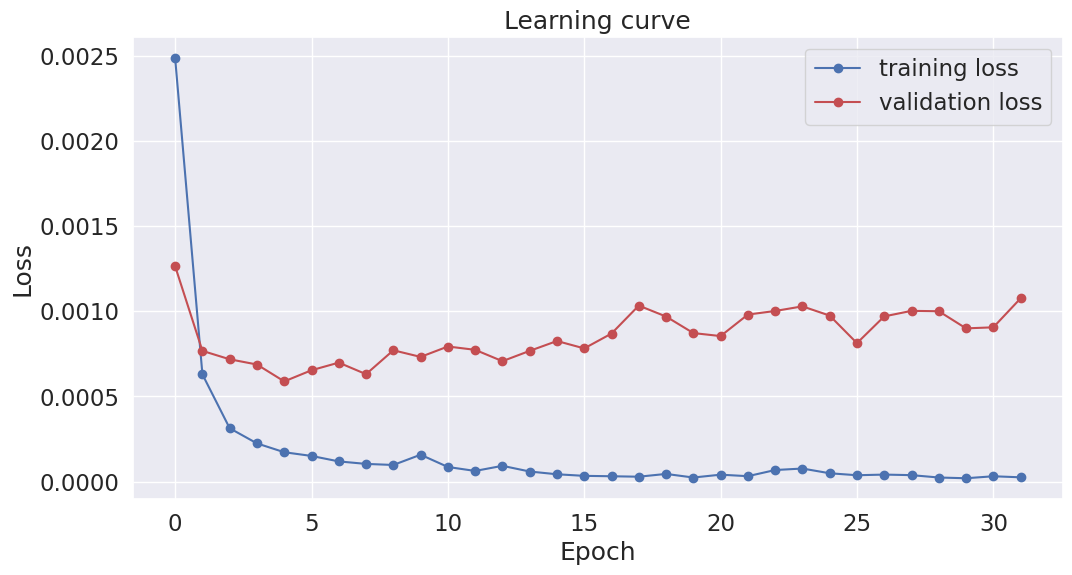

In [9]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### **Eval model**

In [ ]:
print("1.1. Creating NER data // Test data")
# dict_data_test = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v3/test")
dict_data_test = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v2/test")
df_data_test = pd.DataFrame(list(dict_data_test.items()), columns=["archivo_origen", "Text"])

# dict_ann_test = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v3/test")
dict_ann_test = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v2/test")
df_ann_test = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test.items()])
# df_ann = None

data_prepared_test, all_window_labels_test, file_names_test = prepare_data_SYNC(df_data_test, data_ann=df_ann_test, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

1.1. Creating NER data // Test data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/240 [00:00<?, ?te…

Token indices sequence length is longer than the specified maximum sequence length for this model (829 > 512). Running this sequence through the model will result in indexing errors


In [ ]:
id2label = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/CT-EBM-SP/id2label_bio_nerclassifier.json")
label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/CT-EBM-SP/label2id_bio_nerclassifier.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}
dataset_full_test, data_loader_full_test, _, _ = construct_loaders_ner_SYNC(data_prepared_test, all_window_labels_test, file_names_test, ner_type="bio", label2id=label2id, id2label=id2label, seed=SEED)

config.modelo_ner[1] = initialize_bio_ner_model(ctx, model_ner, len(id2label), "NERTraining/BIO/CT-EBM-SP/bio_nerclassifier_checkpoint.pt")

In [12]:
results = run_bio_nerclassifier_SYNC(config.modelo_ner[1], data_loader=data_loader_full_test, device=ctx.device, id2label=id2label, train=False)

BIO NER / Inference:   0%|          | 0/30 [00:00<?, ?batch/s]


Classification report:
              precision    recall  f1-score   support

        DISO     0.9244    0.9278    0.9261      7024
        Date     0.8138    0.8729    0.8424       606
        LIVB     0.9572    0.9427    0.9499      2916
     Neg_cue     0.9039    0.9445    0.9238       757
    Spec_cue     0.7632    0.8974    0.8249       273

   micro avg     0.9205    0.9291    0.9248     11576
   macro avg     0.8725    0.9171    0.8934     11576
weighted avg     0.9217    0.9291    0.9252     11576



## **Results to .ann format**

In [16]:
from SARVI.services.common.utils.ann_utils import ner_outputs_to_ann
from SARVI.data_io.writing import write_ann_list

In [20]:
ann_format = ner_outputs_to_ann(results, id2label, data_loader=data_loader_full_test, original_texts=df_data_test, tokenizer=tokenizer_ner)
write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / ctx.folder_and_archive_name / "results")
# write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / "CT-EBM-SP-v2/test" / "bio")

## **NER results**

In [15]:
from SARVI.services.common.ner_funcs import classification_report_ner

In [16]:
# dict_ann_test_true = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v3/test")
dict_ann_test_true = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v2/test")
df_ann_test_true = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_true.items()])

# dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / ctx.folder_and_archive_name / "bio")
dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / "CT-EBM-SP-v2/test" / "bio")
df_ann_test_pred = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_pred.items()])

label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/label2id_span_nerclassifier.json")

In [17]:
results = classification_report_ner(df_ann_test_true, df_ann_test_pred, [k for k in label2id.keys() if k != "O"])

              precision    recall  f1-score   support   type_1   type_2   type_3   type_4   type_5

        LIVB     0.9310    0.8880    0.9090      1687       10       43        9       44       93
        Date     0.6649    0.6947    0.6795       357       13       13        0        6       90
    Spec_cue     0.7039    0.8333    0.7632       174       23        4        0        6       19
     Neg_cue     0.8992    0.8958    0.8975       518       19       21        3       11       19
        DISO     0.8689    0.8788    0.8739      2550       38       25        2       14      268

   micro avg     0.8700    0.8695    0.8697      5286      103      106       14       81      489
   macro avg     0.8136    0.8381    0.8246      5286      103      106       14       81      489
weighted avg     0.8725    0.8695    0.8706      5286      103      106       14       81      489
